In [ ]:
import pandas as pd
import re


# ReAct not there
desired_order = [
    "MSP",
    "EBO",
    "Entropy",
    "Mahalanobis",
    "ViM",
    "DICE",
    "Ensemble",
    "LogicOOD",
    "LogicOOD+",
    "MLN-Prob",
    "MLN-OOD",
    "MLN-OOD-Untrained",
    "MLN+OOD",
]


path = "outputs/2024-08-27/10-30-20/results-agg.pkl"

df = pd.read_pickle(path)


for metric in ["AUROC", "AUPR-IN", "AUPR-OUT", "FPR95TPR"]:
    df[(metric, "mean", "sem")] = df[(metric, "mean", "sem")].apply(
        lambda x: "$\pm {:.2f}$".format(x)
    )

reordered_df = df.reindex(desired_order)

s = reordered_df.to_latex(float_format="{:.2f}".format)
# s = s.replace("Logic", "Naïve Logic").replace("MLN-OOD-Untrained", "MLN-OOD (Untrained)")

s = re.sub(r"&", r"& & &", s, count=1)

print(s)

In [ ]:
import torch

In [ ]:
import seaborn as sb
import matplotlib.pyplot as plt
import torch

# Enable LaTeX rendering in matplotlib
plt.rcParams.update(
    {
        "text.usetex": True,  # Use LaTeX to render text
        "font.family": "serif",
        "text.latex.preamble": r"\usepackage{amsmath, amssymb}",  # Load required packages,
        "pdf.fonttype": 42,  # Ensure fonts are stored as Type 42 (TrueType) for best quality in PDFs
        "ps.fonttype": 42,
        "text.usetex": True,  # Use LaTeX for text rendering
        "font.serif": ["Times"],  # Set Times as the default serif font
    }
)

a = r"$\text{male}(z) \rightarrow \neg \text{makeup}(z)$"
b = r"$\neg \text{male}(z) \rightarrow \neg \text{beard}(z)$"
c = r"$\text{young}(z) \oplus \text{gray\_hair}(z)$"

weights = torch.load("outputs/2025-01-23/17-55-43/mln-0.pt", map_location="cpu")

# Create the figure and axis objects
fig, ax = plt.subplots()
fig.set_size_inches(8, 4)  # Adjust width and height
# Increase font size for better readability
plt.rcParams.update({"font.size": 18})

# Plot the data
ax.barh([a, b, c], weights[:3])

# Adjust the x-axis limit
# ax.set_xlim(0.9, 1.3)

# Add x-axis label
ax.set_xlabel("Weights")

for index, value in enumerate(weights):
    ax.text(value + 0.005, index, f"{value:.2f}", va="center", fontsize=14)

# Increase the size of the tick labels
ax.tick_params(axis="both", labelsize=18)  # which='major',

ax.xaxis.grid(True, linestyle="--", alpha=0.6)
# Ensure the layout is tight and save the figure
plt.tight_layout(pad=1)
plt.savefig("/home/ki/weights-celeb-a.pdf", bbox_inches="tight")
plt.show()

In [ ]:
a = r"$\text{male}(z) \rightarrow \neg \text{makeup}(z)$"
b = r"$\neg \text{male}(z) \rightarrow \neg \text{beard}(z)$"
c = r"$\text{young}(z) \oplus \text{gray\_hair}(z)$"
d = r"$\text{in_distribution}(z) $"

weights = torch.load("outputs/2024-09-07/13-11-36/mln-oe-0.pt", map_location="cpu")

# Create the figure and axis objects
fig, ax = plt.subplots()
fig.set_size_inches(8, 4)  # Adjust width and height
# Increase font size for better readability
plt.rcParams.update({"font.size": 18})

# Plot the data
ax.barh([a, b, c, d], weights)

# Adjust the x-axis limit
ax.set_xlim(0.9, 1.7)

# Add x-axis label
ax.set_xlabel("Weights")

for index, value in enumerate(weights):
    ax.text(value + 0.005, index, f"{value:.2f}", va="center", fontsize=14)

# Increase the size of the tick labels
ax.tick_params(axis="both", labelsize=18)  # which='major',

ax.xaxis.grid(True, linestyle="--", alpha=0.6)
# Ensure the layout is tight and save the figure
plt.tight_layout(pad=1)
plt.savefig("/home/ki/weights-celeb-a-oe.pdf", bbox_inches="tight")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np
import seaborn as sb
import pandas as pd
from omegaconf import OmegaConf

# LaTeX formatted labels
# a = r"$\forall z \quad \text{male}(z) \rightarrow \neg \text{makeup}(z)$"
# b = r"$\forall z \quad \neg \text{male}(z) \rightarrow \neg \text{beard}(z)$"
# c = r"$\forall z \quad \text{young}(z) \oplus \text{gray\_hair}(z)$"
# d = r"$\forall z \quad \text{in_distribution}(z) $"
labels = range(5)
sb.set_style("white")
cfg = OmegaConf.load("outputs/2025-01-23/17-55-43/.hydra/config.yaml")
l = cfg.constraints

labels = []

for c in cfg.constraints:
    c = c.replace("not", "\\neg").replace("->", "\\rightarrow").replace("_", "\\_")
    # \\forall z \\quad
    labels.append(f"${c}$")

# Number of models
num_models = 10

# Load weights from each model
all_weights = []

for i in range(num_models):
    weights = torch.load(f"outputs/2025-01-23/17-55-43/mln-{i}.pt", map_location="cpu")
    all_weights.append(weights.numpy())  # Store each model's weights

df = pd.DataFrame(all_weights)
df.to_csv("/home/ki/mln-oe-celeb-a-weights.csv")


# Convert to numpy array for easier handling (shape: num_models x num_weights_per_model)
all_weights = np.array(df.values)

# Plot histogram of weights
fig, axes = plt.subplots(len(labels), 1, figsize=(8, 6), sharex=True)

# Increase font size for better readability
plt.rcParams.update({"font.size": 18})

# Plot histograms for each weight across the models
for idx, ax in enumerate(axes):
    # ax.hist(all_weights[:, idx], bins=10, alpha=0.7, color='blue')
    sb.kdeplot(all_weights[:, idx], ax=ax, shade=True, bw_adjust=1.0)  # color='blue',
    ax.set_title(f"{labels[idx]}")  # , loc='left'
    ax.set_ylabel("")
    # ax.set_xlim([0.9, 1.7])
    sb.despine(left=True, right=True, top=True)

# Set a common xlabel for the bottom subplot
axes[-1].set_xlabel("Weight Value")

# Ensure tight layout and save the figure
plt.tight_layout(pad=1)
plt.savefig("/home/ki/weights-distribution-celeb-a-oe.pdf", bbox_inches="tight")
plt.show()

In [ ]:
all_weights

In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np

# LaTeX formatted labels
a = r"$\forall z \quad \text{male}(z) \rightarrow \neg \text{makeup}(z)$"
b = r"$\forall z \quad \neg \text{male}(z) \rightarrow \neg \text{beard}(z)$"
c = r"$\forall z \quad \text{young}(z) \oplus \text{gray\_hair}(z)$"
labels = [a, b, c]

# Number of models
num_models = 10

# Load weights from each model
all_weights = []

for i in range(num_models):
    weights = torch.load(f"outputs/2024-09-07/14-01-03/mln-{i}.pt", map_location="cpu")
    all_weights.append(weights.numpy())  # Store each model's weights

# Convert to numpy array for easier handling (shape: num_models x num_weights_per_model)
all_weights = np.array(all_weights)

# Plot histogram of weights
fig, axes = plt.subplots(len(labels), 1, figsize=(8, 4), sharex=True)

# Increase font size for better readability
plt.rcParams.update({"font.size": 18})

# Plot histograms for each weight across the models
for idx, ax in enumerate(axes):
    # ax.hist(all_weights[:, idx], bins=10, alpha=0.7, color='blue')
    sb.kdeplot(all_weights[:, idx], ax=ax, shade=True, bw_adjust=1.0)  # color='blue',
    ax.set_title(f"{labels[idx]}")  # , loc='left'
    ax.set_ylabel("")
    ax.set_xlim([0.9, 1.7])
    sb.despine(left=True, right=True, top=True)

# Set a common xlabel for the bottom subplot
axes[-1].set_xlabel("Weight Value")

# Ensure tight layout and save the figure
plt.tight_layout(pad=1)
plt.savefig("/home/ki/weights-distribution-celeb-a.pdf", bbox_inches="tight")
plt.show()

In [ ]:
df = pd.read_pickle("outputs/2024-08-27/10-30-20/results.pkl")

In [ ]:
df_tmp = (
    df[["Seed", "Method", "AUROC"]].groupby(["Seed", "Method"]).mean().reset_index()
)

a = df_tmp[df_tmp["Method"] == "MLN-OOD"]["AUROC"].values
b = df_tmp[df_tmp["Method"] == "LogicOOD"]["AUROC"].values

In [ ]:
from scipy.stats import ttest_rel, ttest_ind

#  the mean of the distribution underlying the first sample is greater than the mean of the distribution underlying the second sample.
ttest_rel(a, b, alternative="greater")

In [ ]:
from numpy import mean, std  # version >= 1.7.1
from math import sqrt


def cohen_d(x, y):
    return (mean(x) - mean(y)) / sqrt((std(x, ddof=1) ** 2 + std(y, ddof=1) ** 2) / 2.0)


# cohens_d = (mean(c0) - mean(c1)) / (sqrt((stdev(c0) ** 2 + stdev(c1) ** 2) / 2))

print(cohen_d(a, b))

In [ ]:
import pandas as pd
import seaborn as sb

df = pd.read_csv("stats.csv")
df["iteration"] = range(len(df))

In [ ]:
sb.lineplot(df, x="iteration", y="best_performance")

In [ ]:
#

In [ ]:
from os.path import join
from omegaconf import OmegaConf
import pandas as pd

root = "multirun/sweep-delta"

results = []

for i in range(6):
    path = join(root, str(i))
    cfg = OmegaConf.load(join(path, ".hydra", "config.yaml"))
    df = pd.read_csv(join(path, "stats.csv"))
    r = {
        "delta": cfg.min_delta,
        "n_constraints": df["constraints:"].apply(lambda x: len(x.split(","))).max(),
        "perf": df["best_performance"].max(),
        "constraints": df["constraints:"].values[-1],
    }

    results.append(r)

In [ ]:
results

In [ ]:
import pandas as pd
import seaborn as sb

df = pd.DataFrame(results)
import matplotlib.pyplot as plt
import seaborn as sb

# Set the figure size
plt.figure(figsize=(12, 8))  # Width, Height in inches

# Create the scatter plot
sb.scatterplot(df, x="delta", y="perf", hue="constraints", size="n_constraints")

# Show the plot
plt.savefig("/home/ki/plot.png")

In [ ]:
for col in df.columns:
    print(col)
    df[col]

In [ ]:
df["constraints:"].apply(lambda x: len(x.split(",")))

In [37]:
from functools import lru_cache
from shared import train_mln
from os.path import join

from compiler import ConstraintCompiler
from omegaconf import OmegaConf
import torch
import pandas as pd
from tqdm.auto import tqdm
from mln import MLN
from detectors import get_predictions, MLNEnsembleDetector, EnsembleDetector

cfg = OmegaConf.load(
    join(
        "/home/ki/projects/work/mln-ood/celeb-a/multirun/sweep-delta-hd/0/",
        ".hydra",
        "config.yaml",
    )
)

cfg.paths.predictions = "/run/media/ki/data/mln-ood/celeba/predictions/resnet18/"
print(cfg)

attribute_index_map = {k: n for n, k in enumerate(cfg.attributes)}
print(attribute_index_map)
compiler = ConstraintCompiler(attribute_index_map)

root = "multirun/sweep-delta-hd"
#  "multirun/2024-11-22/17-48-52/"
# root2 = "multirun/2024-11-25/18-33-07/"

results = []


def proc(path):
    cfg = OmegaConf.load(join(path, ".hydra", "config.yaml"))
    df = pd.read_csv(join(path, "stats.csv"))
    r = {
        "delta": cfg.min_delta,
        "n_constraints": df["constraints:"].apply(lambda x: len(x.split(","))).max(),
        "perf": df["best_performance"].max(),
        "constraints": df["constraints:"].values[-1],
    }
    return r


for i in range(11):
    path = join(root, str(i))
    results.append(proc(path))

df = pd.DataFrame(results)


def fix_att_names(sentence):
    for att in cfg.attributes:
        sentence = sentence.replace(att.replace("_", " "), att)
    return sentence


# @lru_cache(maxsize=10)
def load_data(cfg, seed):
    data_train = torch.load(
        join(cfg.paths.predictions, f"data-{cfg.mln.train_on}-{seed:05d}.pt"),
        weights_only=False,
    )
    data_train = {k.lower(): v for k, v in data_train.items()}

    data_in = torch.load(
        join(cfg.paths.predictions, f"data-{cfg.validate_on}-{seed:05d}.pt"),
        weights_only=False,
    )
    data_in = {k.lower(): v for k, v in data_in.items()}

    data_ood = torch.load(
        join(cfg.paths.predictions, f"data-{cfg.dataset}-{seed:05d}.pt"),
        weights_only=False,
    )
    data_ood = {k.lower(): v for k, v in data_ood.items()}
    return data_in, data_ood, data_train


def train_and_eval(cfg, constraints, seed):
    r = []

    data_in, data_ood, data_train = load_data(cfg, seed)
    mln = MLN(
        constraints=constraints,
        domain=[range(2) for _ in cfg.attributes],
    )

    train_data = get_predictions(data_train, cfg.attributes)

    train_mln(cfg, mln, train_data, use_prog=False)

    print(mln.w.data.tolist())

    mln_detector = MLNEnsembleDetector(
        mln, ensemble_attributes=cfg.attributes, mln_attributes=cfg.attributes
    )
    mln_detector.fit(cfg, data_train)

    ensemble_detector = EnsembleDetector(attributes=cfg.attributes)
    ensemble_detector.fit(cfg, data_train)

    #  ["Textures"]:
    #
    for dataset in [
        "LSUNCrop",
        "LSUNResize",
        "TinyImageNetCrop",
        "TinyImageNetResize",
        "Places365",
        "iNaturalist",
        "GaussianNoise",
        "UniformNoise",
    ]:
        print(f"Dataset: {dataset}, seed: {seed}")
        cfg.dataset = dataset
        cfg.validate_on = "test"
        cfg.mln.train_on = "val"

        print(cfg)

        data_in, data_ood, data_train = load_data(cfg, seed)

        performance = mln_detector.evaluate(cfg, data_in, data_ood).compute()
        performance.update({"dataset": dataset, "seed": seed, "method": "MLN+Ensemble"})
        print(performance)
        r.append(performance)

        performance = ensemble_detector.evaluate(cfg, data_in, data_ood).compute()
        performance.update({"dataset": dataset, "seed": seed, "method": "Ensemble"})
        print(performance)
        r.append(performance)

    return r


results = []

for i, (delta, n_con, val_auroc, con) in tqdm(df.iterrows(), total=len(df)):
    c = [
        fix_att_names(c.strip().replace("_", " "))
        for c in con.strip("[]").replace("'", "").replace("implies", "->").split(",")
    ]

    global_namespace = {"torch": torch}
    namespace = {}

    for input_constraint in c:
        # input_constraint = "male -> not makeup"
        constraint_name = (
            input_constraint.replace(" ", "_")
            .replace("->", "implies")
            .replace("(", "")
            .replace(")", "")
        )

        generated_code = compiler.compile(constraint_name, input_constraint)
        print(generated_code)

        # Execute the generated code within this namespace
        exec(generated_code, global_namespace, namespace)

    rule_fn = list(namespace.values())

    print(len(rule_fn))

    for seed in range(10):
        metrics = train_and_eval(cfg, rule_fn, seed=seed)

        for m in metrics:
            metrics_df = {}
            metrics_df.update(m)
            # metrics_df["constraints"] = [c[:] for _ in range(len(metrics_df))]
            metrics_df["val_auroc"] = val_auroc
            metrics_df["n_constraints"] = len(rule_fn)
            metrics_df["i"] = i
            metrics_df["delta"] = delta
            results.append(metrics_df)

            rdf = pd.DataFrame(results)
            rdf.to_csv("/home/ki/results-ablation-celeba-deltamin.csv")

{'device': 'cuda', 'backbone': 'resnet18', 'n_seeds': 5, 'paths': {'root': '/run/media/ki/data/datasets/', 'models': '/run/media/ki/data/mln-ood/celeba/models/${backbone}/', 'predictions': '/run/media/ki/data/mln-ood/celeba/predictions/resnet18/'}, 'dataset': 'Textures', 'validate_on': 'test', 'min_delta': 0.0, 'attributes': ['blond_hair', 'gray_hair', 'receding_hairline', 'heavy_makeup', 'brown_hair', 'young', 'wearing_lipstick', 'mustache', 'male', 'goatee', 'attractive', 'bald', 'no_beard'], 'mln': {'train_on': 'val', 'epochs': 10, 'batch_size': 40000, 'lr': 0.01}}
{'blond_hair': 0, 'gray_hair': 1, 'receding_hairline': 2, 'heavy_makeup': 3, 'brown_hair': 4, 'young': 5, 'wearing_lipstick': 6, 'mustache': 7, 'male': 8, 'goatee': 9, 'attractive': 10, 'bald': 11, 'no_beard': 12}


  0%|          | 0/11 [00:00<?, ?it/s]

def young(x):
    young = x[:, 5] == 1
    return torch.where(young, 1, 0).unsqueeze(1)
def attractive(x):
    attractive = x[:, 10] == 1
    return torch.where(attractive, 1, 0).unsqueeze(1)
def no_beard(x):
    no_beard = x[:, 12] == 1
    return torch.where(no_beard, 1, 0).unsqueeze(1)
def not_young(x):
    young = x[:, 5] == 1
    return torch.where(~(young), 1, 0).unsqueeze(1)
def not_attractive(x):
    attractive = x[:, 10] == 1
    return torch.where(~(attractive), 1, 0).unsqueeze(1)
def blond_hair_implies_no_beard(x):
    blond_hair = x[:, 0] == 1
    no_beard = x[:, 12] == 1
    return torch.where((~(blond_hair)) | (no_beard), 1, 0).unsqueeze(1)
def blond_hair_implies_not_gray_hair(x):
    blond_hair = x[:, 0] == 1
    gray_hair = x[:, 1] == 1
    return torch.where((~(blond_hair)) | (~(gray_hair)), 1, 0).unsqueeze(1)
def gray_hair_implies_not_attractive(x):
    gray_hair = x[:, 1] == 1
    attractive = x[:, 10] == 1
    return torch.where((~(gray_hair)) | (~(attractive)), 1, 

In [43]:
rdf = pd.DataFrame(results)

In [44]:
rdf.to_csv("/home/ki/results-ablation-celeba-deltamin.csv")

In [45]:
rdf

,AUROC,AUTC,AUPR-IN,AUPR-OUT,FPR95TPR,dataset,seed,method,val_auroc,n_constraints,i,delta
0,0.855234,0.390617,0.970317,0.501436,0.34644,LSUNCrop,0,MLN+Ensemble,0.930219,40,0,0.00
1,0.913913,0.356159,0.980543,0.752529,0.38490,LSUNCrop,0,Ensemble,0.930219,40,0,0.00
2,0.886549,0.389867,0.977188,0.511558,0.32944,LSUNResize,0,MLN+Ensemble,0.930219,40,0,0.00
3,0.822585,0.422903,0.960471,0.459712,0.49532,LSUNResize,0,Ensemble,0.930219,40,0,0.00
4,0.818174,0.391908,0.962991,0.350007,0.36602,TinyImageNetCrop,0,MLN+Ensemble,0.930219,40,0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...
1755,0.851065,0.414014,0.967305,0.508920,0.44716,iNaturalist,9,Ensemble,0.900091,1,10,0.05
1756,0.992365,0.351841,0.999848,0.564575,0.01970,GaussianNoise,9,MLN+Ensemble,0.900091,1,10,0.05
1757,0.989416,0.269574,0.999789,0.484418,0.02706,GaussianNoise,9,Ensemble,0.900091,1,10,0.05
1758,0.984504,0.353586,0.999690,0.404188,0.03382,UniformNoise,9,MLN+Ensemble,0.900091,1,10,0.05


In [46]:
# rdf.to_pickle("multirun/2024-11-22/17-48-52/result_df.pkl")

/home/ki/.local/share/anaconda3/envs/pytorch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/ki/.local/share/anaconda3/envs/pytorch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/ki/.local/share/anaconda3/envs/pytorch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/ki/.local/share/anaconda3/envs/pytorch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning

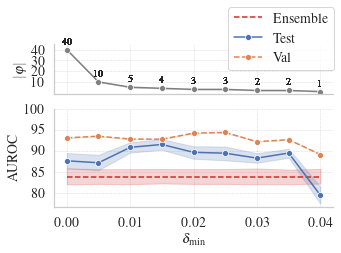

In [54]:
import seaborn as sb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import seaborn as sb
import pandas as pd
import matplotlib.pyplot as plt

gridline_style = {"color": "gray", "linestyle": "--", "linewidth": 0.5, "alpha": 0.3}

sb.set("paper")
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sb.set_theme(style="whitegrid", rc=custom_params, font_scale=1.5)

my_fontsize = 14

# Configure matplotlib to use Times and Helvetica
plt.rcParams.update(
    {
        "pdf.fonttype": 42,  # Ensure fonts are stored as Type 42 (TrueType) for best quality in PDFs
        "ps.fonttype": 42,
        "text.usetex": True,  # Use LaTeX for text rendering
        "font.family": "serif",  # Use serif fonts (Times in this case)
        "font.serif": ["Times"],  # Set Times as the default serif font
        "text.latex.preamble": r"\usepackage{amsmath, amssymb}",  # Load required packages,
        "axes.labelsize": my_fontsize,  # Font size for axis labels (10pt as per WACV)
        "xtick.labelsize": my_fontsize,  # Font size for x-tick labels
        "ytick.labelsize": my_fontsize,  # Font size for y-tick labels
        "legend.fontsize": my_fontsize,  # Font size for legend text
        "figure.titlesize": my_fontsize,  # Font size for figure title (optional)
        "axes.titlesize": my_fontsize,  # Font size for axes titles
        "legend.fontsize": my_fontsize,  # Font size for legend text
    }
)


rdf_tmp = rdf.copy()
# rdf_tmp = rdf_tmp[rdf_tmp["Method"] == "MLN+Ensemble"].groupby(by=["Seed", "delta"])[["AUROC", "n_constraints", "val_auroc"]].mean().reset_index()
# rdf_tmp = rdf_tmp.groupby(by=["Seed", "delta"])[["AUROC", "n_constraints", "val_auroc"]].mean().reset_index()

rdf_tmp["val_auroc"] = rdf_tmp["val_auroc"].apply(lambda x: x * 100)
rdf_tmp["AUROC"] = rdf_tmp["AUROC"].apply(lambda x: x * 100)
rdf_tmp = rdf_tmp[rdf_tmp["delta"] < 0.0425]

# Create a figure with two subplots arranged vertically
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(5, 3), gridspec_kw={"height_ratios": [1.5, 3]}
)  # Height ratios define size of the two plots

# Top plot: n_rules vs delta
sb.lineplot(rdf_tmp, x="delta", y="n_constraints", marker="o", ax=ax1, color="tab:grey")
ax1.set_xlabel("")
# ax1.set_xlabel(r"$\delta_{\text{min}}$")
ax1.set_ylabel(r"$\vert \varphi \vert$")
ax1.tick_params(axis="x", labelbottom=False)  # Hide x-axis tick labels
# ax1.set_title("Rules vs Delta")
ax1.set_yticks([10, 20, 30, 40])
ax1.set_ylim([-1, 45])
# ax1.yaxis.set_label_coords(-0.2, 0)

# Add a numeric label for each point
for x_val, y_val in zip(rdf_tmp["delta"], rdf_tmp["n_constraints"]):
    ax1.text(
        x_val,
        y_val + 3,  # slightly shift upwards (y_val+1)
        f"{int(y_val)}",  # format as you like
        ha="center",
        va="bottom",
        fontsize=10,
    )


# Bottom plot: delta vs AUROC
sb.lineplot(
    rdf_tmp[rdf_tmp["method"] == "Ensemble"],
    x="delta",
    y="AUROC",
    linestyle="--",
    label="Ensemble",
    ax=ax2,
    color="tab:red",
)
sb.lineplot(
    rdf_tmp[rdf_tmp["method"] == "MLN+Ensemble"],
    x="delta",
    y="AUROC",
    marker="o",
    label="Test",
    ax=ax2,
)
sb.lineplot(
    rdf_tmp, x="delta", y="val_auroc", marker="o", label="Val", ax=ax2, linestyle="--"
)
ax2.set_xlabel(r"$\delta_{\text{min}}$")
ax2.set_ylabel("AUROC")
ax2.set_yticks([80, 85, 90, 95, 100])  # 50, 60, 70, 80,
# ax2.set_xlim([0, 0.0425])

ax1.grid(**gridline_style)
ax2.grid(**gridline_style)
# Adjust layout to prevent overlap
# sb.move_legend(ax2, "upper left", bbox_to_anchor=(1, 1))
plt.legend(loc="upper left", bbox_to_anchor=(0.6, 2.1))  #  bbox_to_anchor=(1, 1.75)

# Show the plot
# plt.tight_layout(pad=1)
plt.savefig("/home/ki/delta-study.pdf", bbox_inches="tight")  # ,

In [ ]:
rdf["val_auroc_tmp"] = rdf["val_auroc"] * 100

In [ ]:
rdf = pd.DataFrame(results)
rdf["n_constraints"] = rdf["constraints"].apply(lambda x: len(x))
rdf["val_auroc_tmp"] = rdf["val_auroc"] * 100

In [ ]:
# Create a figure with two subplots arranged vertically
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(5, 3), gridspec_kw={"height_ratios": [1, 3]}
)  # Height ratios define size of the two plots

# Top plot: n_rules vs delta
sb.lineplot(rdf, x="delta", y="n_constraints", marker="o", ax=ax1)
ax1.set_xlabel(r"$\delta_{\text{min}}$")
ax1.set_ylabel(r"$\vert \phi \vert$")
# ax1.set_title("Rules vs Delta")

# Bottom plot: delta vs AUROC
sb.lineplot(rdf, x="delta", y="test_auroc", marker="o", label="Test", ax=ax2)
sb.lineplot(rdf, x="delta", y="val_auroc_tmp", marker="o", label="Val", ax=ax2)
ax2.set_xlabel(r"$\delta_{\text{min}}$")
ax2.set_ylabel("AUROC")

ax1.grid(**gridline_style)
ax2.grid(**gridline_style)
# Adjust layout to prevent overlap

In [ ]:
df2 = pd.read_pickle("multirun/2024-11-22/17-48-52/result_df.pkl")

In [ ]:
df2

In [ ]:
# Create a figure with two subplots arranged vertically
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(5, 3), gridspec_kw={"height_ratios": [1.5, 3]}
)  # Height ratios define size of the two plots

# Define the x-axis ticks
x_ticks = pd.concat([rdf, df2])["delta"].unique()
x_ticks.sort()  # Ensure sorted x-ticks for consistency

# Top plot: n_rules vs delta
sb.lineplot(
    data=pd.concat([rdf, df2]),
    x="delta",
    y="n_constraints",
    ax=ax1,
    marker="o",
    color="tab:grey",
)
# xax1.axhline(0, color="gray", linestyle="--", linewidth=1)  # Add horizontal 0-line
ax1.set_ylim([0, 15])
ax1.set_xlabel(r"")
ax1.set_ylabel(r"$\vert \varphi \vert$")
ax1.set_yticks([0, 5, 10, 15])
# ax1.set_xticks([])
ax1.tick_params(axis="x", labelbottom=False)  # Hide x-axis tick labels
ax1.grid(**gridline_style)

# Bottom plot: delta vs AUROC
sb.lineplot(
    data=pd.concat([rdf, df2]),
    x="delta",
    y="test_auroc",
    marker="o",
    label="Test",
    ax=ax2,
)
sb.lineplot(
    data=pd.concat([rdf, df2]),
    x="delta",
    y="val_auroc_tmp",
    marker="o",
    label="Val",
    ax=ax2,
)
ax2.set_xlabel(r"$\delta_{\text{min}}$")
ax2.set_ylabel("AUROC")
ax2.grid(**gridline_style)

# Adjust layout to prevent overlap
plt.tight_layout(pad=0)
plt.savefig("/home/ki/results.pdf", bbox_inches="tight")

In [ ]:
x_ticks

In [1]:
import pandas as pd
import re


# ReAct not there
desired_order = [
    "MSP",
    "EBO",
    "Entropy",
    "Ensemble",
    "Mahalanobis",
    "ViM",
    "SHE",
    "ReAct",
    "DICE",
    "Logic",
    "Logic+Ensemble",
    "MLN",
    "MLN+Ensemble",
    "MLN+Mahalanobis",
    # "Logic+Ensemble+",
    # "MLN+Ensemble+",
    # "MLN+ViM+",
    # "MLN+Mahalanobis+",
]

path = (
    "/home/ki/projects/work/mln-ood/celeb-a/outputs/2025-02-27/13-24-28/results-agg.pkl"
)

df = pd.read_pickle(path)


for metric in ["AUROC", "AUPR-IN", "AUPR-OUT", "FPR95TPR"]:
    df[(metric, "mean", "sem")] = df[(metric, "mean", "sem")].apply(
        lambda x: "$\pm {:.2f}$".format(x)
    )

reordered_df = df.reindex(desired_order)

s = reordered_df.to_latex(float_format="{:.2f}".format)
# s = s.replace("Logic", "Naïve Logic").replace("MLN-OOD-Untrained", "MLN-OOD (Untrained)")

s = re.sub(r"&", r"& & &", s, count=1)

print(s)

\begin{tabular}{lrlrlrlrl}
\toprule
 & & & \multicolumn{2}{r}{AUROC} & \multicolumn{2}{r}{AUPR-IN} & \multicolumn{2}{r}{AUPR-OUT} & \multicolumn{2}{r}{FPR95TPR} \\
 & \multicolumn{2}{r}{mean} & \multicolumn{2}{r}{mean} & \multicolumn{2}{r}{mean} & \multicolumn{2}{r}{mean} \\
 & mean & sem & mean & sem & mean & sem & mean & sem \\
Method &  &  &  &  &  &  &  &  \\
\midrule
MSP & 48.68 & $\pm 4.09$ & 85.06 & $\pm 3.29$ & 13.42 & $\pm 2.89$ & 85.59 & $\pm 9.54$ \\
EBO & 45.24 & $\pm 4.60$ & 82.56 & $\pm 5.62$ & 12.96 & $\pm 3.03$ & 77.22 & $\pm 7.69$ \\
Entropy & 33.83 & $\pm 6.21$ & 68.95 & $\pm 5.04$ & 11.01 & $\pm 2.47$ & 87.69 & $\pm 8.16$ \\
Ensemble & 83.41 & $\pm 2.35$ & 95.20 & $\pm 1.87$ & 48.49 & $\pm 4.02$ & 43.14 & $\pm 7.24$ \\
Mahalanobis & 95.12 & $\pm 1.18$ & 98.72 & $\pm 0.36$ & 80.68 & $\pm 3.78$ & 17.77 & $\pm 3.98$ \\
ViM & 84.94 & $\pm 3.82$ & 93.75 & $\pm 2.93$ & 69.62 & $\pm 6.51$ & 48.59 & $\pm 11.30$ \\
SHE & 39.78 & $\pm 2.91$ & 82.63 & $\pm 5.38$ & 12.22 & $\pm 

In [56]:
# compute gain on different base detectors
import pandas as pd

path = "outputs/2025-01-24/17-39-35/results-agg.pkl"

df = pd.read_pickle(path)

markup = "\color{green}{\scriptsize $\Delta$"
markup_end = "}"


for detector in [
    "MSP",
    "Ensemble",
    "EBO",
    "DICE",
    "SHE",
    "ReAct",
    "Mahalanobis",
    "ViM",
]:
    perf1 = df.loc[detector]["AUROC"]["mean"]["mean"]
    perf2 = df.loc[f"MLN+{detector}"]["AUROC"]["mean"]["mean"]
    perf3 = df.loc[f"MLN+{detector}+"]["AUROC"]["mean"]["mean"]

    print(
        f"{detector:<15} & {perf1:>5.2f} & {perf2:>5.2f}  {markup} {perf2 - perf1:>5.2f} {markup_end} & {perf3:>5.2f}  {markup} {perf3 - perf2:>5.2f} {markup_end} \\\\ "
    )

MSP             & 48.68 & 60.72  \color{green}{\scriptsize $\Delta$ 12.04 } & 71.10  \color{green}{\scriptsize $\Delta$ 10.38 } \\ 
Ensemble        & 83.43 & 90.42  \color{green}{\scriptsize $\Delta$  6.99 } & 97.42  \color{green}{\scriptsize $\Delta$  7.00 } \\ 
EBO             & 45.24 & 73.89  \color{green}{\scriptsize $\Delta$ 28.65 } & 89.89  \color{green}{\scriptsize $\Delta$ 16.00 } \\ 
DICE            & 46.83 & 74.98  \color{green}{\scriptsize $\Delta$ 28.16 } & 90.31  \color{green}{\scriptsize $\Delta$ 15.32 } \\ 
SHE             & 39.78 & 71.54  \color{green}{\scriptsize $\Delta$ 31.76 } & 89.75  \color{green}{\scriptsize $\Delta$ 18.21 } \\ 
ReAct           & 44.84 & 72.06  \color{green}{\scriptsize $\Delta$ 27.22 } & 89.55  \color{green}{\scriptsize $\Delta$ 17.49 } \\ 
Mahalanobis     & 95.12 & 96.01  \color{green}{\scriptsize $\Delta$  0.89 } & 97.86  \color{green}{\scriptsize $\Delta$  1.85 } \\ 
ViM             & 84.94 & 91.75  \color{green}{\scriptsize $\Delta$  6.82 } 